<a href="https://colab.research.google.com/github/shreyasacharya1/ML/blob/main/1BM23CS320_Lab_9_AdaBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy (10 trees): 0.8182004299314157
Confusion Matrix:
 [[6782  632]
 [1144 1211]]


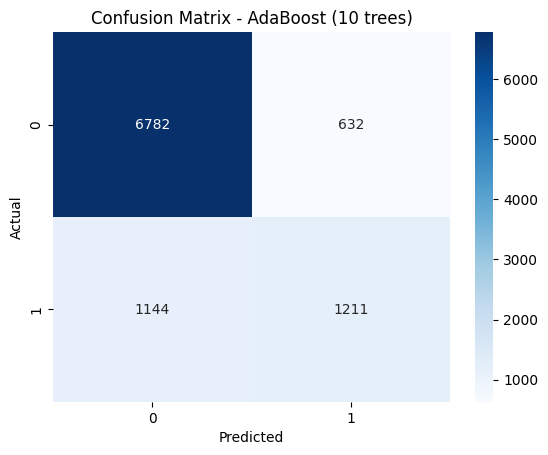

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('income.csv')

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

X = df.drop('income_level', axis=1)
y = df['income_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = AdaBoostClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy (10 trees):", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - AdaBoost (10 trees)")
plt.show()

In [ ]:
trees = [10, 50, 100, 150, 200]

best_score = 0
best_n = 0

for n in trees:
    model = AdaBoostClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Trees: {n}, Accuracy: {acc}")

    if acc > best_score:
        best_score = acc
        best_n = n

print("\nBest Accuracy:", best_score)
print("Best Number of Trees:", best_n)

Trees: 10, Accuracy: 0.8182004299314157
Trees: 50, Accuracy: 0.8327362063670796
Trees: 100, Accuracy: 0.8328385709898659
Trees: 150, Accuracy: 0.8329409356126523
Trees: 200, Accuracy: 0.8332480294810114

Best Accuracy: 0.8332480294810114
Best Number of Trees: 200


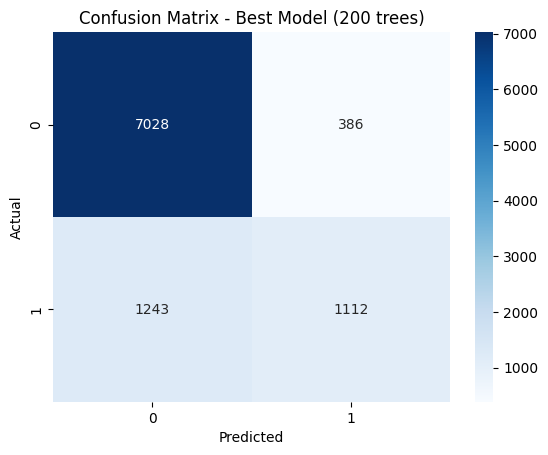

In [ ]:
final_model = AdaBoostClassifier(n_estimators=best_n, random_state=42)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - Best Model ({best_n} trees)")
plt.show()